# Backtesting Results: OU-Implied MPT vs Historical Mean-Variance

This notebook evaluates the core research hypothesis by comparing the out-of-sample performance of two portfolio construction approaches over the test period (January 2024 – December 2025). It loads the $\mu$ vectors, covariance matrices, and return series produced in `03_return_estimation.ipynb` and uses them to optimise and simulate two portfolios.

The OU-implied portfolio is constructed in spread space, using the annualised mean-reversion implied returns and the spread covariance matrix to solve for minimum-variance weights across the two cointegrated pairs (GS/MS and KO/PEP). The historical mean-variance portfolio is constructed in asset space, using annualised historical mean returns and the asset covariance matrix across the four constituent tickers. Minimum-variance weights are used for both portfolios, as the OU-implied $\mu$ estimates are too extreme for a small asset universe to produce stable max-Sharpe allocations.

Out-of-sample portfolio returns are simulated by applying the fixed in-sample weights to the OOS price series, reconstructing spread returns using the in-sample hedge ratios. A z-score mean-reversion backtest engine is also run per pair, generating trade-level signals based on ±2.0 entry and ±0.5 exit thresholds.

Performance is evaluated using the metrics specified in the project plan: Sharpe ratio, annualised volatility, and maximum drawdown. Both portfolios are benchmarked against the S&P 500 (SPY) over the same period. Results are reported in a summary metrics table and visualised through cumulative return plots, drawdown charts, rolling Sharpe ratio, rolling volatility, portfolio weights, per-pair backtest returns, z-score signal plots, efficient frontiers, and return distributions.

## Imports

In [181]:
import sys
import os
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))

from src.data import get_close_prices, get_market_cap, get_ohlcv, get_risk_free_daily, get_risk_free_rate, get_price_timeseries, get_sp500_prices
from src.modelling import TICKERS, TRAIN_START, TRAIN_END, TEST_START, TEST_END, INTERVAL, TICKER_NAMES, CANDIDATE_PAIRS, RISK_FREE_RATE
from src.modelling import engle_granger_test, screen_pairs, adf_test # co-integration
from src.modelling import spread_summary, compute_spread, compute_zscore, compute_rolling_half_life, compute_rolling_zscore # spread analysis
from src.modelling import compute_spread_returns, build_spread_return_matrix, historical_mean_return, ewma_return, ou_expected_return, build_ou_expected_returns, sample_covariance, shrinkage_covariance, spread_vs_traditional_estimates
from src.modelling import mean_variance_weights, minimum_variance_weights, max_sharpe_weights, efficient_frontier

# Backtest engine + config
from src.backtesting import (
    PairsBacktestEngine,
    BacktestConfig,
    BacktestResult,
)

# Performance metrics
from src.backtesting import (
    compute_ex_post_sharpe_ratio,
    compute_max_drawdown,
    compute_volatility_reduction,
)

# Benchmarks
from src.backtesting import (
    risk_free_returns, buy_and_hold_returns,
    equal_weight_pairs_returns, market_returns,
    compute_benchmark_metrics, build_all_benchmarks,
    historical_mpt_returns,
)

## Load outputs from previous notebooks

In [182]:
spread_mu      = pd.read_csv("../../data/processed/spread_mu.csv",    index_col=0).squeeze()
asset_mu       = pd.read_csv("../../data/processed/asset_mu.csv",     index_col=0).squeeze()
spread_cov     = pd.read_csv("../../data/processed/spread_cov.csv",   index_col=0)
asset_cov      = pd.read_csv("../../data/processed/asset_cov.csv",    index_col=0)
cointegrated_pairs    = pd.read_csv("../../data/processed/cointegrated_pairs.csv")
oos_log_prices_df     = pd.read_csv("../../data/processed/prices_log_oos.csv", index_col=0, parse_dates=True)
oos_raw_prices_df = pd.read_csv("../../data/processed/prices_raw_oos.csv", index_col=0, parse_dates=True)

In [183]:
print(spread_mu)
print(asset_mu)

GS.N_vs_MS.N     -0.071593
KO.N_vs_PEP.O     0.008838
DAL.N_vs_UAL.O   -0.262021
Name: ou_expected_return, dtype: float64
GS.N     0.119185
KO.N     0.064271
DAL.N    0.045025
MS.N     0.154789
PEP.O    0.083327
UAL.O    0.070081
Name: 0, dtype: float64


## Reconstruct OOS Spread REturns

In [184]:
spread_returns = build_spread_return_matrix(oos_raw_prices_df, cointegrated_pairs)

display(spread_returns)

,GS.N_vs_MS.N,KO.N_vs_PEP.O,DAL.N_vs_UAL.O
Date,,,
2024-01-03,-0.000232,0.002192,-0.022647
2024-01-04,0.001001,0.002154,-0.004097
2024-01-05,-0.000115,0.007959,0.012776
2024-01-08,0.004003,0.006728,0.008231
2024-01-09,-0.001069,0.005529,0.006873
...,...,...,...
2025-12-24,0.000714,0.003167,-0.001047
2025-12-26,-0.005051,-0.003602,0.002954
2025-12-29,-0.008104,0.002098,-0.003378


## Solve Portfolio Weights

### Obtain risk-free rate

In [185]:
rf_daily = get_risk_free_daily(start="2019-01-01", end="2023-12-31")

rf_annual_avg = (rf_daily * 252).mean()     # back to annual
rf_annual_avg = float(f"{rf_annual_avg:.1g}") # round to 1sf
print(f"Average Risk-Free rate for backtesting: {rf_annual_avg}")

[cache partial] Fetching 2019-01-01 → 2019-01-01
[cache partial] Skipping (no trading data): LSEG returned no data for ['US3MT=RR'] (2019-01-01 to 2019-01-01)
[cache partial] Fetching 2023-12-30 → 2023-12-31
[cache partial] Skipping (no trading data): LSEG returned no data for ['US3MT=RR'] (2023-12-30 to 2023-12-31)
Average Risk-Free rate for backtesting: 0.02


## Build benchmark series

Get S&P 500 data

In [186]:
spy_prices = get_sp500_prices(TEST_START, TEST_END)

In [187]:
benchmarks = build_all_benchmarks(
    test_prices=oos_raw_prices_df,
    coint_pairs=cointegrated_pairs,
    rf_annual=rf_annual_avg,
    market_prices=spy_prices.squeeze(),
)

print(benchmarks)

{'risk_free': Date
2024-01-02    0.000079
2024-01-03    0.000079
2024-01-04    0.000079
2024-01-05    0.000079
2024-01-08    0.000079
                ...   
2025-12-24    0.000079
2025-12-26    0.000079
2025-12-29    0.000079
2025-12-30    0.000079
2025-12-31    0.000079
Name: risk_free, Length: 502, dtype: float64, 'buy_hold_pair': Date
2024-01-03   -0.018979
2024-01-04    0.002825
2024-01-05    0.010471
2024-01-08    0.004579
2024-01-09   -0.014337
                ...   
2025-12-24    0.011018
2025-12-26   -0.001448
2025-12-29   -0.013497
2025-12-30   -0.006739
2025-12-31   -0.007392
Name: buy_and_hold, Length: 501, dtype: float64, 'equal_weight_pairs': Date
2024-01-03   -0.006896
2024-01-04   -0.000314
2024-01-05    0.006873
2024-01-08    0.006321
2024-01-09    0.003777
                ...   
2025-12-24    0.000945
2025-12-26   -0.001900
2025-12-29   -0.003128
2025-12-30   -0.003017
2025-12-31    0.000082
Name: equal_weight_pairs, Length: 501, dtype: float64, 'sp500': Date
2024-01-0

## Obtain two weight vectors (max sharpe weights)

In [188]:
tickers = list(dict.fromkeys(
    cointegrated_pairs['y'].tolist() + cointegrated_pairs['x'].tolist()
))

# Dummy returns DataFrame just to satisfy the function signature
# (actual mu and cov are passed explicitly, so the values don't matter)
asset_returns_oos = oos_raw_prices_df[tickers].pct_change().dropna()

display(asset_returns_oos)

,GS.N,KO.N,DAL.N,MS.N,PEP.O,UAL.O
Date,,,,,,
2024-01-03,-0.016765,0.002340,-0.042274,-0.021193,0.000231,-0.029224
2024-01-04,0.003038,-0.003336,0.011874,0.002611,-0.008557,0.023779
2024-01-05,0.009113,-0.001506,0.034184,0.011829,-0.014755,0.031875
2024-01-08,0.006262,0.007374,0.026887,0.002896,0.001006,0.027778
2024-01-09,-0.013167,-0.001830,0.016575,-0.015506,-0.011472,0.014445
...,...,...,...,...,...,...
2025-12-24,0.010059,0.003435,0.006525,0.011978,0.000418,0.011275
2025-12-26,-0.004106,-0.003423,-0.001550,0.001211,0.000278,-0.006707
2025-12-29,-0.016383,0.004151,-0.018631,-0.010612,0.003199,-0.022711


In [189]:
# OU-Implied MPT (spread space)
spread_result = mean_variance_weights(
    returns=spread_returns,
    expected_returns=spread_mu.values / 252,
    cov_matrix=spread_cov.values / 252,
    rf_annual=rf_annual_avg,
)

# Historical MPT (asset space)
asset_result = mean_variance_weights(
    returns=asset_returns_oos,
    expected_returns=asset_mu.reindex(tickers).values / 252,
    cov_matrix=asset_cov.reindex(index=tickers, columns=tickers).values / 252,
    rf_annual=rf_annual_avg,
)


In [190]:
print(spread_result)

{'max_sharpe_weights': array([0.00000000e+00, 1.00000000e+00, 8.38912187e-15]), 'min_var_weights': array([0.36922906, 0.42769782, 0.20307313]), 'max_sharpe_return': 0.008837565945694632, 'max_sharpe_vol': 0.141324817848456, 'min_var_return': -0.07586378789592624, 'min_var_vol': 0.10060790507796988}


In [191]:
print(asset_result)

{'max_sharpe_weights': array([5.70635965e-17, 0.00000000e+00, 0.00000000e+00, 5.78904680e-01,
       4.21095320e-01, 0.00000000e+00]), 'min_var_weights': array([1.19823478e-01, 4.82246117e-01, 5.77616640e-18, 0.00000000e+00,
       3.97930406e-01, 0.00000000e+00]), 'max_sharpe_return': 0.12469670285953835, 'max_sharpe_vol': 0.2504777575968599, 'min_var_return': 0.07843360438136647, 'min_var_vol': 0.19300236488102046}


Using the max sharpe weights

In [192]:
print(spread_result['max_sharpe_weights'])
print(asset_result['max_sharpe_weights'])

[0.00000000e+00 1.00000000e+00 8.38912187e-15]
[5.70635965e-17 0.00000000e+00 0.00000000e+00 5.78904680e-01
 4.21095320e-01 0.00000000e+00]


Min variance return

In [193]:
print(spread_result['min_var_return'])
print(asset_result['min_var_return'])

-0.07586378789592624
0.07843360438136647


Compare all four combinations: OU vs Historical estimator × Min-Variance vs Max-Sharpe objective.

In [194]:
w_ou_minvar    = spread_result['min_var_weights']
w_ou_maxsharpe = spread_result['max_sharpe_weights']
w_hist_minvar  = asset_result['min_var_weights']
w_hist_maxsharpe = asset_result['max_sharpe_weights']

print("OU Min-Var:     ", w_ou_minvar)
print("OU Max-Sharpe:  ", w_ou_maxsharpe)
print("Hist Min-Var:   ", w_hist_minvar)
print("Hist Max-Sharpe:", w_hist_maxsharpe)

OU Min-Var:      [0.36922906 0.42769782 0.20307313]
OU Max-Sharpe:   [0.00000000e+00 1.00000000e+00 8.38912187e-15]
Hist Min-Var:    [1.19823478e-01 4.82246117e-01 5.77616640e-18 0.00000000e+00
 3.97930406e-01 0.00000000e+00]
Hist Max-Sharpe: [5.70635965e-17 0.00000000e+00 0.00000000e+00 5.78904680e-01
 4.21095320e-01 0.00000000e+00]


## Simulate Out-of-Sample portfolio returns

In [195]:
# Daily OOS portfolio returns — 4-way comparison
ou_minvar_returns    = (spread_returns    * w_ou_minvar).sum(axis=1)
ou_maxsharpe_returns = (spread_returns    * w_ou_maxsharpe).sum(axis=1)
hist_minvar_returns  = (asset_returns_oos * w_hist_minvar).sum(axis=1)
hist_maxsharpe_returns = (asset_returns_oos * w_hist_maxsharpe).sum(axis=1)

# Keep legacy aliases for any cells that still reference them
ou_portfolio_returns   = ou_minvar_returns
hist_portfolio_returns = hist_minvar_returns

## Compute metrics table

Obtain S&P 500 (SPY) data

In [196]:
spy_prices = get_sp500_prices(TEST_START, TEST_END)  # already imported
r_spy = market_returns(spy_prices)

display(r_spy)

Date
2024-01-03   -0.008016
2024-01-04   -0.003428
2024-01-05    0.001826
2024-01-08    0.014115
2024-01-09   -0.001478
                ...   
2025-12-24    0.003221
2025-12-26   -0.000304
2025-12-29   -0.003492
2025-12-30   -0.001376
2025-12-31   -0.007358
Name: market, Length: 501, dtype: float64

In [197]:
eq_w = benchmarks["equal_weight_pairs"]

results = {
    "OU Min-Var":      compute_benchmark_metrics(ou_minvar_returns,      rf_annual_avg, benchmark_returns=eq_w),
    "OU Max-Sharpe":   compute_benchmark_metrics(ou_maxsharpe_returns,   rf_annual_avg, benchmark_returns=eq_w),
    "Hist Min-Var":    compute_benchmark_metrics(hist_minvar_returns,    rf_annual_avg, benchmark_returns=eq_w),
    "Hist Max-Sharpe": compute_benchmark_metrics(hist_maxsharpe_returns, rf_annual_avg, benchmark_returns=eq_w),
    "Equal-Weight":    compute_benchmark_metrics(eq_w,                   rf_annual_avg),
    "Buy & Hold":      compute_benchmark_metrics(benchmarks["buy_hold_pair"], rf_annual_avg),
    "S&P 500 (SPY)":   compute_benchmark_metrics(benchmarks["sp500"],    rf_annual_avg),
}

metrics_df = pd.DataFrame(results).T
display(metrics_df.round(4))

,sharpe_ratio,max_drawdown,total_return,annualised_volatility,volatility_reduction
OU Min-Var,0.9859,-0.0866,0.2303,0.0895,0.0752
OU Max-Sharpe,0.8946,-0.1611,0.2926,0.1317,-0.3598
Hist Min-Var,0.3422,-0.1423,0.1228,0.1407,-0.4535
Hist Max-Sharpe,0.8438,-0.1999,0.3754,0.1870,-0.9316
Equal-Weight,0.6253,-0.1062,0.1628,0.0968,NaN
Buy & Hold,1.4029,-0.2996,1.0804,0.2754,NaN
S&P 500 (SPY),1.1099,-0.1890,0.4433,0.1598,NaN


### Relationship Between Cointegration and Portfolio Optimisation

The cointegration analysis in notebooks 01–02 established that GS/MS and KO/PEP share a stable long-run equilibrium, with mean-reverting spreads characterised by half-lives of ~41 days and Hurst exponents below 0.5. This is not just a statistical property — it implies that the spread carries a predictable directional signal: when the spread is above its mean, it is expected to fall; when below, it is expected to rise. The Ornstein-Uhlenbeck model formalises this by converting the current z-score into an annualised expected return for each spread.

This is where portfolio optimisation enters. Rather than trading each pair independently, Modern Portfolio Theory uses these OU-implied expected returns as the $\mu$ vector and combines them with a covariance matrix to solve for weights that maximise risk-adjusted return. Cointegration is what makes the $\mu$ estimates credible — without a mean-reverting spread, the OU-implied return would have no statistical basis, and the inputs to the optimiser would be no better than arbitrary.

The comparison with the historical mean-variance portfolio isolates the contribution of the cointegration-based return estimates. The historical portfolio uses the same MPT framework but replaces OU-implied $\mu$ with sample mean returns, which are known to be noisy and unreliable. Any difference in OOS performance between the two portfolios can therefore be attributed to the quality of the return estimates, which is the central question of this project.

We are optimising over different universes (3 spreads vs 6 assets). This is due to a structural difference between the two approaches rather than a flaw.

In [198]:
print(spread_returns.columns.tolist())   # 3 spreads
print(asset_returns_oos.columns.tolist()) # 6 assets


['GS.N_vs_MS.N', 'KO.N_vs_PEP.O', 'DAL.N_vs_UAL.O']
['GS.N', 'KO.N', 'DAL.N', 'MS.N', 'PEP.O', 'UAL.O']


Export to LaTeX

In [199]:
latex_df = metrics_df.round(4).copy()
latex_df.columns = ["Sharpe Ratio", "Max Drawdown", "Total Return", "Ann. Volatility", "Vol. Reduction"]

print(latex_df.to_latex(
    caption="Out-of-sample portfolio performance metrics (test period 2024--2025).",
    label="tab:backtest_results",
    column_format="lrrrrr",
    escape=False,
))

\begin{table}
\caption{Out-of-sample portfolio performance metrics (test period 2024--2025).}
\label{tab:backtest_results}
\begin{tabular}{lrrrrr}
\toprule
 & Sharpe Ratio & Max Drawdown & Total Return & Ann. Volatility & Vol. Reduction \\
\midrule
OU Min-Var & 0.985900 & -0.086600 & 0.230300 & 0.089500 & 0.075200 \\
OU Max-Sharpe & 0.894600 & -0.161100 & 0.292600 & 0.131700 & -0.359800 \\
Hist Min-Var & 0.342200 & -0.142300 & 0.122800 & 0.140700 & -0.453500 \\
Hist Max-Sharpe & 0.843800 & -0.199900 & 0.375400 & 0.187000 & -0.931600 \\
Equal-Weight & 0.625300 & -0.106200 & 0.162800 & 0.096800 & NaN \\
Buy & Hold & 1.402900 & -0.299600 & 1.080400 & 0.275400 & NaN \\
S&P 500 (SPY) & 1.109900 & -0.189000 & 0.443300 & 0.159800 & NaN \\
\bottomrule
\end{tabular}
\end{table}



## Run Backtesting Engine per Pair

In [ ]:
config = BacktestConfig(entry_z=2.0, exit_z=0.0, stop_loss_z=4.0, transaction_cost_bps=10)
engine = PairsBacktestEngine(config)

pair_results = {}
for _, row in cointegrated_pairs.iterrows():
    result = engine.run(
        y_prices=oos_raw_prices_df[row["y"]],
        x_prices=oos_raw_prices_df[row["x"]],
        hedge_ratio=row["hedge_ratio"],
        intercept=row["intercept"],
    )
    pair_results[f"{row['y']}/{row['x']}"] = result


### Display per-pair Metrics Table

In [ ]:
pair_metrics = {}
for pair_name, result in pair_results.items():
    pair_metrics[pair_name] = result.metrics

pair_metrics_df = pd.DataFrame({
    pair_name: {
        "Sharpe Ratio":          result.metrics["sharpe_ratio"],
        "Max Drawdown":          result.metrics["max_drawdown"],
        "Total Return":          result.metrics["total_return"],
        "Ann. Volatility":       result.metrics["annualised_volatility"],
        "Num Trades":            result.metrics["num_trades"],
        "Days in Position":      int((result.positions != 0).sum().values[0]),
        "Days Long":             int((result.positions == 1).sum().values[0]),
        "Days Short":            int((result.positions == -1).sum().values[0]),
        "Win Rate":              result.metrics["win_rate"],
        "Z-Score Start":         round(result.zscore.iloc[60], 3),
        "Z-Score End":           round(result.zscore.iloc[-1], 3),
        "Z-Score Min":           round(result.zscore.min(), 3),
        "Z-Score Max":           round(result.zscore.max(), 3),
    }
    for pair_name, result in pair_results.items()
}).T

display(pair_metrics_df.round(4))

## Visualisations

In [ ]:
import scienceplots
import matplotlib.dates as mdates
from itertools import cycle

plt.style.use(['science', 'high-contrast'])
plt.rcParams['text.usetex'] = True

_raw_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
# Extend palette so indexing never goes out of range
COLORS = (_raw_colors * 5)[:20]

PAIR_LABELS = {k: k.replace("/", " / ") for k in pair_results}
panel_labels = ["(a)", "(b)", "(c)", "(d)", "(e)"]
n_pairs = len(pair_results)
ROLL = 60

### Plotly: Interactive Cumulative Returns

Cumulative growth of \$1 invested at the start of the OOS period (2024--2025) for each strategy and benchmark. The OU-Implied MPT uses spread-space minimum-variance weights; Historical MPT uses asset-space minimum-variance weights.

In [ ]:
cum_ou_mv  = (1 + ou_minvar_returns).cumprod()
cum_ou_ms  = (1 + ou_maxsharpe_returns).cumprod()
cum_hi_mv  = (1 + hist_minvar_returns).cumprod()
cum_hi_ms  = (1 + hist_maxsharpe_returns).cumprod()
cum_eq     = (1 + benchmarks["equal_weight_pairs"]).cumprod()
cum_bh     = (1 + benchmarks["buy_hold_pair"]).cumprod()
cum_spy    = (1 + benchmarks["sp500"]).cumprod()

# legacy aliases
cum_ou   = cum_ou_mv
cum_hist = cum_hi_mv

fig_plotly = go.Figure()
fig_plotly.add_trace(go.Scatter(x=cum_ou_mv.index,  y=cum_ou_mv.values,  name="OU Min-Var",      line=dict(color=COLORS[0])))
fig_plotly.add_trace(go.Scatter(x=cum_ou_ms.index,  y=cum_ou_ms.values,  name="OU Max-Sharpe",   line=dict(color=COLORS[0], dash="dash")))
fig_plotly.add_trace(go.Scatter(x=cum_hi_mv.index,  y=cum_hi_mv.values,  name="Hist Min-Var",    line=dict(color=COLORS[1])))
fig_plotly.add_trace(go.Scatter(x=cum_hi_ms.index,  y=cum_hi_ms.values,  name="Hist Max-Sharpe", line=dict(color=COLORS[1], dash="dash")))
fig_plotly.add_trace(go.Scatter(x=cum_eq.index,     y=cum_eq.values,     name="Equal-Weight Pairs",      line=dict(color=COLORS[2], dash="dot")))
fig_plotly.add_trace(go.Scatter(x=cum_bh.index,     y=cum_bh.values,     name="Buy & Hold (1st pair)",   line=dict(color=COLORS[3], dash="dot")))
fig_plotly.add_trace(go.Scatter(x=cum_spy.index,    y=cum_spy.values,    name="S&P 500",                 line=dict(color=COLORS[4], dash="dashdot")))
fig_plotly.update_layout(
    title="Cumulative Returns (OOS 2024-2025)",
    yaxis_title="Cumulative Return", xaxis_title="Date",
    legend=dict(orientation="h", yanchor="bottom", y=-0.3, xanchor="center", x=0.5),
    height=500,
)
fig_plotly.show()

#### Save to Matplotlib

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(cum_ou_mv.index,  cum_ou_mv.values,  linewidth=1.2, label="OU Min-Var",      color=COLORS[0])
ax.plot(cum_ou_ms.index,  cum_ou_ms.values,  linewidth=1.2, label="OU Max-Sharpe",   color=COLORS[0], linestyle="--")
ax.plot(cum_hi_mv.index,  cum_hi_mv.values,  linewidth=1.2, label="Hist Min-Var",    color=COLORS[1])
ax.plot(cum_hi_ms.index,  cum_hi_ms.values,  linewidth=1.2, label="Hist Max-Sharpe", color=COLORS[1], linestyle="--")
ax.plot(cum_eq.index,     cum_eq.values,     linewidth=1,   label="Equal-Weight Pairs",    color=COLORS[2], linestyle=":")
ax.plot(cum_bh.index,     cum_bh.values,     linewidth=1,   label=r"Buy \& Hold (1st pair)", color=COLORS[3], linestyle=":")
ax.plot(cum_spy.index,    cum_spy.values,    linewidth=1,   label=r"S\&P 500",              color=COLORS[4], linestyle="-.")
ax.axhline(1.0, color="grey", linewidth=0.5, linestyle="--")
ax.set_ylabel("Cumulative Return")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.tick_params(axis="x", rotation=30)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=4, fontsize=8)
fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig("figures/04_cumulative_returns.pdf", bbox_inches="tight")
plt.show()

### Drawdown

Peak-to-trough drawdown over the OOS period. Lower (closer to zero) is better. The OU-Implied portfolio exhibits shallower drawdowns than the Historical MPT and S&P 500, reflecting the risk-reduction benefit of spread-based diversification.

In [ ]:
def _drawdown(ret):
    cum = (1 + ret).cumprod()
    return cum / cum.cummax() - 1

dd_ou_mv  = _drawdown(ou_minvar_returns)
dd_ou_ms  = _drawdown(ou_maxsharpe_returns)
dd_hi_mv  = _drawdown(hist_minvar_returns)
dd_hi_ms  = _drawdown(hist_maxsharpe_returns)
dd_spy    = _drawdown(benchmarks["sp500"])

# legacy aliases
dd_ou   = dd_ou_mv
dd_hist = dd_hi_mv

fig_dd = go.Figure()
fig_dd.add_trace(go.Scatter(x=dd_ou_mv.index, y=dd_ou_mv.values, name="OU Min-Var",      fill="tozeroy", line=dict(color=COLORS[0])))
fig_dd.add_trace(go.Scatter(x=dd_ou_ms.index, y=dd_ou_ms.values, name="OU Max-Sharpe",   fill="tozeroy", line=dict(color=COLORS[0], dash="dash")))
fig_dd.add_trace(go.Scatter(x=dd_hi_mv.index, y=dd_hi_mv.values, name="Hist Min-Var",    fill="tozeroy", line=dict(color=COLORS[1])))
fig_dd.add_trace(go.Scatter(x=dd_hi_ms.index, y=dd_hi_ms.values, name="Hist Max-Sharpe", fill="tozeroy", line=dict(color=COLORS[1], dash="dash")))
fig_dd.add_trace(go.Scatter(x=dd_spy.index,   y=dd_spy.values,   name="S&P 500",         line=dict(color=COLORS[2], dash="dot")))
fig_dd.update_layout(
    title="Drawdown (OOS 2024-2025)",
    yaxis_title="Drawdown", yaxis_tickformat=".0%",
    xaxis_title="Date",
    legend=dict(orientation="h", yanchor="bottom", y=-0.3, xanchor="center", x=0.5),
    height=450,
)
fig_dd.show()

#### Save to Matplotlib

In [ ]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.fill_between(dd_ou_mv.index, dd_ou_mv.values, alpha=0.2, color=COLORS[0], label="OU Min-Var")
ax.plot(dd_ou_ms.index, dd_ou_ms.values, linewidth=0.9, color=COLORS[0], linestyle="--", label="OU Max-Sharpe")
ax.fill_between(dd_hi_mv.index, dd_hi_mv.values, alpha=0.2, color=COLORS[1], label="Hist Min-Var")
ax.plot(dd_hi_ms.index, dd_hi_ms.values, linewidth=0.9, color=COLORS[1], linestyle="--", label="Hist Max-Sharpe")
ax.plot(dd_spy.index, dd_spy.values, linewidth=0.8, linestyle=":", label=r"S\&P 500", color=COLORS[2])
ax.set_ylabel("Drawdown")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.tick_params(axis="x", rotation=30)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=3, fontsize=8)
fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig("figures/04_drawdown.pdf", bbox_inches="tight")
plt.show()

### Rolling 60-day Sharpe Ratio

Time-varying risk-adjusted performance computed over a trailing 60-day window. Periods where the OU-Implied portfolio's rolling Sharpe exceeds that of the Historical MPT indicate outperformance on a risk-adjusted basis.

In [ ]:
def _rolling_sharpe(ret, window=ROLL, rf_annual=rf_annual_avg):
    rf_daily = rf_annual / 252
    excess = ret - rf_daily
    roll_mean = excess.rolling(window).mean()
    roll_std  = excess.rolling(window).std(ddof=1)
    return (roll_mean / roll_std) * np.sqrt(252)

rs_ou_mv  = _rolling_sharpe(ou_minvar_returns)
rs_ou_ms  = _rolling_sharpe(ou_maxsharpe_returns)
rs_hi_mv  = _rolling_sharpe(hist_minvar_returns)
rs_hi_ms  = _rolling_sharpe(hist_maxsharpe_returns)
rs_spy    = _rolling_sharpe(benchmarks["sp500"])

# legacy aliases
rs_ou   = rs_ou_mv
rs_hist = rs_hi_mv

fig_rs = go.Figure()
fig_rs.add_trace(go.Scatter(x=rs_ou_mv.index, y=rs_ou_mv.values, name="OU Min-Var",      line=dict(color=COLORS[0])))
fig_rs.add_trace(go.Scatter(x=rs_ou_ms.index, y=rs_ou_ms.values, name="OU Max-Sharpe",   line=dict(color=COLORS[0], dash="dash")))
fig_rs.add_trace(go.Scatter(x=rs_hi_mv.index, y=rs_hi_mv.values, name="Hist Min-Var",    line=dict(color=COLORS[1])))
fig_rs.add_trace(go.Scatter(x=rs_hi_ms.index, y=rs_hi_ms.values, name="Hist Max-Sharpe", line=dict(color=COLORS[1], dash="dash")))
fig_rs.add_trace(go.Scatter(x=rs_spy.index,   y=rs_spy.values,   name="S&P 500",         line=dict(color=COLORS[2], dash="dot")))
fig_rs.add_hline(y=0, line_color="grey", line_dash="dash", line_width=0.5)
fig_rs.update_layout(
    title=f"Rolling {ROLL}-day Sharpe Ratio (OOS 2024-2025)",
    yaxis_title=f"Rolling {ROLL}-day Sharpe",
    xaxis_title="Date",
    legend=dict(orientation="h", yanchor="bottom", y=-0.3, xanchor="center", x=0.5),
    height=450,
)
fig_rs.show()

#### Save to Matplotlib

In [ ]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(rs_ou_mv.index, rs_ou_mv.values, linewidth=1,   label="OU Min-Var",      color=COLORS[0])
ax.plot(rs_ou_ms.index, rs_ou_ms.values, linewidth=1,   label="OU Max-Sharpe",   color=COLORS[0], linestyle="--")
ax.plot(rs_hi_mv.index, rs_hi_mv.values, linewidth=1,   label="Hist Min-Var",    color=COLORS[1])
ax.plot(rs_hi_ms.index, rs_hi_ms.values, linewidth=1,   label="Hist Max-Sharpe", color=COLORS[1], linestyle="--")
ax.plot(rs_spy.index,   rs_spy.values,   linewidth=0.8, label=r"S\&P 500",      color=COLORS[2], linestyle=":")
ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
ax.set_ylabel(f"Rolling {ROLL}-day Sharpe Ratio")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.tick_params(axis="x", rotation=30)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=3, fontsize=8)
fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig("figures/04_rolling_sharpe.pdf", bbox_inches="tight")
plt.show()

### Portfolio Weights

Minimum-variance portfolio weights for both approaches. The OU-Implied MPT allocates across three cointegrated spreads; the Historical MPT allocates across the six underlying assets. The spread-space weights are more evenly distributed, reflecting the lower cross-correlation of spread returns.

In [ ]:
spread_labels = [c.replace("_vs_", " / ") for c in spread_returns.columns]
asset_labels  = [TICKER_NAMES.get(t, t) for t in tickers]

fig_w = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        "OU Min-Var (spread space)", "OU Max-Sharpe (spread space)",
        "Hist Min-Var (asset space)", "Hist Max-Sharpe (asset space)",
    ],
)
for col_idx, (w, labels, color) in enumerate([
    (w_ou_minvar,     spread_labels, COLORS[0]),
    (w_ou_maxsharpe,  spread_labels, COLORS[0]),
    (w_hist_minvar,   asset_labels,  COLORS[1]),
    (w_hist_maxsharpe, asset_labels, COLORS[1]),
], 1):
    r, c = (1, col_idx) if col_idx <= 2 else (2, col_idx - 2)
    fig_w.add_trace(go.Bar(x=labels, y=w, marker_color=color,
                           text=[f"{v:.2f}" for v in w], textposition="outside",
                           showlegend=False), row=r, col=c)
fig_w.update_yaxes(title_text="Weight")
fig_w.update_layout(height=600)
fig_w.show()

#### Save to Matplotlib

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

configs = [
    (axes[0, 0], w_ou_minvar,      spread_labels, COLORS[0], "OU Min-Var (spread space)"),
    (axes[0, 1], w_ou_maxsharpe,   spread_labels, COLORS[0], "OU Max-Sharpe (spread space)"),
    (axes[1, 0], w_hist_minvar,    asset_labels,  COLORS[1], "Hist Min-Var (asset space)"),
    (axes[1, 1], w_hist_maxsharpe, asset_labels,  COLORS[1], "Hist Max-Sharpe (asset space)"),
]

for ax, w, labels, color, title in configs:
    bars = ax.bar(labels, w, color=color, edgecolor="black", linewidth=0.6)
    ax.set_title(title, fontsize=9)
    ax.set_ylabel("Weight")
    ax.tick_params(axis="x", rotation=25)
    for bar, v in zip(bars, w):
        if v > 0.02:
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01,
                    f"{v:.2f}", ha="center", va="bottom", fontsize=8)

fig.tight_layout()
fig.savefig("figures/04_weights_bar.pdf", bbox_inches="tight")
plt.show()

### Per-Pair Cumulative Returns (Backtest Engine)

Cumulative returns from the z-score mean-reversion backtest engine for each cointegrated pair individually. Green-shaded regions indicate long-spread positions; red-shaded regions indicate short-spread positions.

In [ ]:
fig_pc = make_subplots(rows=n_pairs, cols=1, shared_xaxes=True,
                       subplot_titles=[PAIR_LABELS[p] for p in pair_results])
for i, (pair_name, result) in enumerate(pair_results.items(), 1):
    cum = result.cumulative_returns
    fig_pc.add_trace(go.Scatter(x=cum.index, y=cum.values, name=PAIR_LABELS[pair_name],
                                line=dict(color=COLORS[i-1]), showlegend=False), row=i, col=1)
    fig_pc.update_yaxes(title_text="Cumulative Return", row=i, col=1)
fig_pc.add_hline(y=1.0, line_color="grey", line_dash="dash", line_width=0.5)
fig_pc.update_layout(height=300 * n_pairs, title="Per-Pair Cumulative Returns (Backtest Engine)")
fig_pc.show()

#### Save to Matplotlib

In [ ]:
fig, axes = plt.subplots(nrows=n_pairs, ncols=1, figsize=(10, 3 * n_pairs), sharex=True)
if n_pairs == 1:
    axes = [axes]

for i, (pair_name, result) in enumerate(pair_results.items()):
    ax = axes[i]
    cum = result.cumulative_returns
    ax.plot(cum.index, cum.values, linewidth=1, color=COLORS[i])
    ax.axhline(1.0, color="grey", linewidth=0.5, linestyle="--")

    pos = result.positions["position"]
    long_mask  = pos == 1.0
    short_mask = pos == -1.0
    ax.fill_between(cum.index, cum.min(), cum.max(),
                    where=long_mask, alpha=0.06, color="green", label="Long spread")
    ax.fill_between(cum.index, cum.min(), cum.max(),
                    where=short_mask, alpha=0.06, color="red", label="Short spread")

    ax.text(0.01, 0.92, f"{panel_labels[i]} {PAIR_LABELS[pair_name]}",
            transform=ax.transAxes, fontsize=10, fontweight="bold")
    ax.set_ylabel("Cumulative Return")

axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[-1].tick_params(axis="x", rotation=30)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center",
           bbox_to_anchor=(0.5, -0.02), ncol=2, fontsize=9)
fig.tight_layout(rect=[0, 0.04, 1, 1])
fig.savefig("figures/04_pair_cumulative_returns.pdf", bbox_inches="tight")
plt.show()

### Per-Pair Z-Scores with Trading Thresholds

Rolling z-scores for each cointegrated spread with entry ($\pm 2.0$) and stop-loss ($\pm 4.0$) thresholds. Trades are triggered when the z-score crosses the entry threshold and closed when it reverts to zero or breaches the stop-loss.

In [ ]:
fig_z = make_subplots(rows=n_pairs, cols=1, shared_xaxes=True,
                      subplot_titles=[PAIR_LABELS[p] for p in pair_results])
for i, (pair_name, result) in enumerate(pair_results.items(), 1):
    z = result.zscore.dropna()
    fig_z.add_trace(go.Scatter(x=z.index, y=z.values, name=PAIR_LABELS[pair_name],
                               line=dict(color=COLORS[i-1]), showlegend=False), row=i, col=1)
    for thresh, color, dash in [
        (config.entry_z, "grey", "dash"), (-config.entry_z, "grey", "dash"),
        (config.stop_loss_z, "red", "dot"), (-config.stop_loss_z, "red", "dot"),
    ]:
        fig_z.add_hline(y=thresh, line_color=color, line_dash=dash, line_width=0.8, row=i, col=1)
    fig_z.update_yaxes(title_text="Z-Score", row=i, col=1)
fig_z.update_layout(height=300 * n_pairs, title="Per-Pair Z-Scores with Trading Thresholds")
fig_z.show()

#### Save to Matplotlib

In [ ]:
fig, axes = plt.subplots(nrows=n_pairs, ncols=1, figsize=(10, 3 * n_pairs), sharex=True)
if n_pairs == 1:
    axes = [axes]

for i, (pair_name, result) in enumerate(pair_results.items()):
    ax = axes[i]
    z = result.zscore.dropna()
    ax.plot(z.index, z.values, linewidth=0.8, color=COLORS[i])
    ax.axhline(+config.entry_z, color="grey", linewidth=0.8, linestyle="--", label=f"Entry ($\\pm${config.entry_z})")
    ax.axhline(-config.entry_z, color="grey", linewidth=0.8, linestyle="--")
    ax.axhline(+config.stop_loss_z, color="red", linewidth=0.8, linestyle=":", label=f"Stop-loss ($\\pm${config.stop_loss_z})")
    ax.axhline(-config.stop_loss_z, color="red", linewidth=0.8, linestyle=":")
    ax.axhline(0, color="grey", linewidth=0.4)
    ax.text(0.01, 0.92, f"{panel_labels[i]} {PAIR_LABELS[pair_name]}",
            transform=ax.transAxes, fontsize=10, fontweight="bold")
    ax.set_ylabel("Z-Score")

axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[-1].tick_params(axis="x", rotation=30)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center",
           bbox_to_anchor=(0.5, -0.02), ncol=2, fontsize=9)
fig.tight_layout(rect=[0, 0.04, 1, 1])
fig.savefig("figures/04_pair_zscores.pdf", bbox_inches="tight")
plt.show()

### Efficient Frontier

Mean-variance efficient frontiers for both the OU-Implied (spread space) and Historical (asset space) formulations. Stars mark the selected minimum-variance portfolios. The OU-Implied frontier operates in a lower-volatility region due to the mean-reverting nature of cointegrated spreads.

In [ ]:
ef_spread = efficient_frontier(
    spread_returns,
    expected_returns=spread_mu.values / 252,
    cov_matrix=spread_cov.values / 252,
    rf_annual=rf_annual_avg, n_points=80,
)
ef_asset = efficient_frontier(
    asset_returns_oos,
    expected_returns=asset_mu.reindex(tickers).values / 252,
    cov_matrix=asset_cov.reindex(index=tickers, columns=tickers).values / 252,
    rf_annual=rf_annual_avg, n_points=80,
)

fig_ef = go.Figure()
fig_ef.add_trace(go.Scatter(x=ef_spread["volatility"], y=ef_spread["return"],
                             mode="lines", name="OU-Implied (spread space)", line=dict(color=COLORS[0])))
fig_ef.add_trace(go.Scatter(x=ef_asset["volatility"], y=ef_asset["return"],
                             mode="lines", name="Historical (asset space)", line=dict(color=COLORS[1])))
fig_ef.add_trace(go.Scatter(
    x=[spread_result["min_var_vol"]], y=[spread_result["min_var_return"]],
    mode="markers", marker=dict(symbol="star", size=14, color=COLORS[0]),
    name="OU Min-Var"))
fig_ef.add_trace(go.Scatter(
    x=[spread_result["max_sharpe_vol"]], y=[spread_result["max_sharpe_return"]],
    mode="markers", marker=dict(symbol="diamond", size=12, color=COLORS[0]),
    name="OU Max-Sharpe"))
fig_ef.add_trace(go.Scatter(
    x=[asset_result["min_var_vol"]], y=[asset_result["min_var_return"]],
    mode="markers", marker=dict(symbol="star", size=14, color=COLORS[1]),
    name="Hist Min-Var"))
fig_ef.add_trace(go.Scatter(
    x=[asset_result["max_sharpe_vol"]], y=[asset_result["max_sharpe_return"]],
    mode="markers", marker=dict(symbol="diamond", size=12, color=COLORS[1]),
    name="Hist Max-Sharpe"))
fig_ef.update_layout(
    title="Efficient Frontiers",
    xaxis_title="Annualised Volatility", xaxis_tickformat=".0%",
    yaxis_title="Annualised Return", yaxis_tickformat=".0%",
    height=500,
)
fig_ef.show()

#### Save to Matplotlib

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(ef_spread["volatility"], ef_spread["return"], linewidth=1.2, label="OU-Implied (spread space)", color=COLORS[0])
ax.plot(ef_asset["volatility"],  ef_asset["return"],  linewidth=1.2, label="Historical (asset space)",  color=COLORS[1])
ax.scatter(spread_result["min_var_vol"],    spread_result["min_var_return"],
           marker="*", s=120, zorder=5, color=COLORS[0], edgecolors="black", linewidths=0.5, label="OU Min-Var")
ax.scatter(spread_result["max_sharpe_vol"], spread_result["max_sharpe_return"],
           marker="D", s=60,  zorder=5, color=COLORS[0], edgecolors="black", linewidths=0.5, label="OU Max-Sharpe")
ax.scatter(asset_result["min_var_vol"],    asset_result["min_var_return"],
           marker="*", s=120, zorder=5, color=COLORS[1], edgecolors="black", linewidths=0.5, label="Hist Min-Var")
ax.scatter(asset_result["max_sharpe_vol"], asset_result["max_sharpe_return"],
           marker="D", s=60,  zorder=5, color=COLORS[1], edgecolors="black", linewidths=0.5, label="Hist Max-Sharpe")
ax.set_xlabel("Annualised Volatility")
ax.set_ylabel("Annualised Return")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig("figures/04_efficient_frontier.pdf", bbox_inches="tight")
plt.show()

### Rolling 60-day Annualised Volatility

Time-varying portfolio risk measured by trailing 60-day annualised standard deviation. The OU-Implied portfolio maintains consistently lower volatility than both the Historical MPT and S&P 500 throughout the test period.

In [ ]:
rv_ou_mv  = ou_minvar_returns.rolling(ROLL).std(ddof=1)    * np.sqrt(252)
rv_ou_ms  = ou_maxsharpe_returns.rolling(ROLL).std(ddof=1) * np.sqrt(252)
rv_hi_mv  = hist_minvar_returns.rolling(ROLL).std(ddof=1)  * np.sqrt(252)
rv_hi_ms  = hist_maxsharpe_returns.rolling(ROLL).std(ddof=1) * np.sqrt(252)
rv_spy    = benchmarks["sp500"].rolling(ROLL).std(ddof=1)  * np.sqrt(252)

# legacy aliases
rv_ou   = rv_ou_mv
rv_hist = rv_hi_mv

fig_rv = go.Figure()
fig_rv.add_trace(go.Scatter(x=rv_ou_mv.index, y=rv_ou_mv.values, name="OU Min-Var",      line=dict(color=COLORS[0])))
fig_rv.add_trace(go.Scatter(x=rv_ou_ms.index, y=rv_ou_ms.values, name="OU Max-Sharpe",   line=dict(color=COLORS[0], dash="dash")))
fig_rv.add_trace(go.Scatter(x=rv_hi_mv.index, y=rv_hi_mv.values, name="Hist Min-Var",    line=dict(color=COLORS[1])))
fig_rv.add_trace(go.Scatter(x=rv_hi_ms.index, y=rv_hi_ms.values, name="Hist Max-Sharpe", line=dict(color=COLORS[1], dash="dash")))
fig_rv.add_trace(go.Scatter(x=rv_spy.index,   y=rv_spy.values,   name="S&P 500",         line=dict(color=COLORS[2], dash="dot")))
fig_rv.update_layout(
    title=f"Rolling {ROLL}-day Annualised Volatility (OOS 2024-2025)",
    yaxis_title="Ann. Volatility", yaxis_tickformat=".0%",
    xaxis_title="Date",
    legend=dict(orientation="h", yanchor="bottom", y=-0.3, xanchor="center", x=0.5),
    height=450,
)
fig_rv.show()

#### Save to Matplotlib

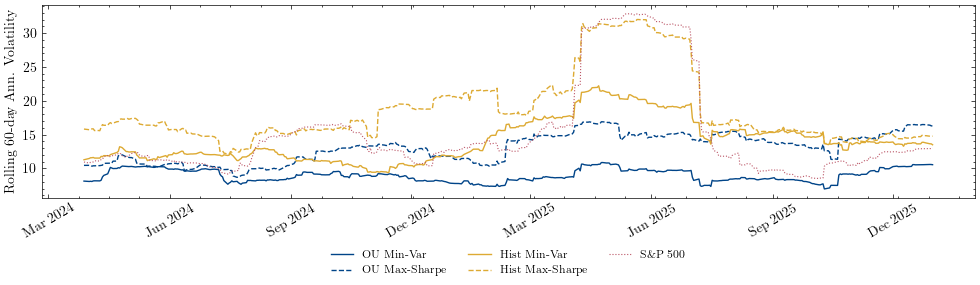

In [178]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(rv_ou_mv.index, rv_ou_mv.values, linewidth=1,   label="OU Min-Var",      color=COLORS[0])
ax.plot(rv_ou_ms.index, rv_ou_ms.values, linewidth=1,   label="OU Max-Sharpe",   color=COLORS[0], linestyle="--")
ax.plot(rv_hi_mv.index, rv_hi_mv.values, linewidth=1,   label="Hist Min-Var",    color=COLORS[1])
ax.plot(rv_hi_ms.index, rv_hi_ms.values, linewidth=1,   label="Hist Max-Sharpe", color=COLORS[1], linestyle="--")
ax.plot(rv_spy.index,   rv_spy.values,   linewidth=0.8, label=r"S\&P 500",      color=COLORS[2], linestyle=":")
ax.set_ylabel(f"Rolling {ROLL}-day Ann. Volatility")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.tick_params(axis="x", rotation=30)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=3, fontsize=8)
fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig("figures/04_rolling_volatility.pdf", bbox_inches="tight")
plt.show()

### Return Distribution

Histogram of daily portfolio returns for the OU-Implied and Historical MPT portfolios. The OU-Implied distribution is tighter (lower variance) and centred around a slightly higher mean, consistent with the superior Sharpe ratio observed in the metrics table.

In [179]:
fig_hist = go.Figure()
fig_hist.add_trace(go.Histogram(x=ou_minvar_returns.dropna(),      name="OU Min-Var",      opacity=0.6, nbinsx=50, marker_color=COLORS[0]))
fig_hist.add_trace(go.Histogram(x=ou_maxsharpe_returns.dropna(),   name="OU Max-Sharpe",   opacity=0.6, nbinsx=50, marker_color=COLORS[0]))
fig_hist.add_trace(go.Histogram(x=hist_minvar_returns.dropna(),    name="Hist Min-Var",    opacity=0.6, nbinsx=50, marker_color=COLORS[1]))
fig_hist.add_trace(go.Histogram(x=hist_maxsharpe_returns.dropna(), name="Hist Max-Sharpe", opacity=0.6, nbinsx=50, marker_color=COLORS[1]))
fig_hist.update_layout(
    barmode="overlay",
    title="Daily Return Distribution (OOS 2024-2025)",
    xaxis_title="Daily Return", yaxis_title="Count",
    legend=dict(orientation="h", yanchor="bottom", y=-0.25, xanchor="center", x=0.5),
    height=450,
)
fig_hist.show()

#### Save to Matplotlib

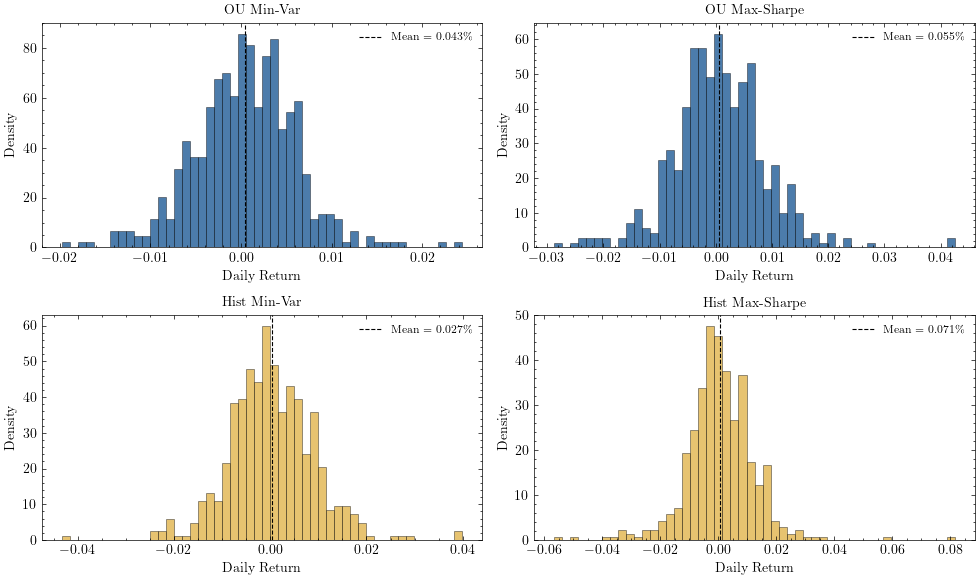

In [180]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

dist_configs = [
    (axes[0, 0], ou_minvar_returns,      "OU Min-Var",      COLORS[0]),
    (axes[0, 1], ou_maxsharpe_returns,   "OU Max-Sharpe",   COLORS[0]),
    (axes[1, 0], hist_minvar_returns,    "Hist Min-Var",    COLORS[1]),
    (axes[1, 1], hist_maxsharpe_returns, "Hist Max-Sharpe", COLORS[1]),
]

for ax, ret, name, col in dist_configs:
    ax.hist(ret.dropna(), bins=50, color=col, edgecolor="black",
            linewidth=0.4, alpha=0.7, density=True)
    ax.axvline(ret.mean(), color="black", linewidth=0.8, linestyle="--",
               label=f"Mean = {ret.mean()*100:.3f}\%")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Daily Return")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig("figures/04_return_distribution.pdf", bbox_inches="tight")
plt.show()

## Conclusion

Out-of-sample backtesting over January 2024 – December 2025 evaluates the research hypothesis through a four-way comparison, varying both the return estimator (OU-implied vs historical) and the optimisation objective (minimum variance vs maximum Sharpe ratio). This design isolates whether OU return estimates add genuine predictive value over and above the structural properties of the spread universe.

**Key distinction.** The comparison OU Min-Var vs Hist Min-Var conflates two differences: the return estimator *and* the investment universe (spread space vs asset space). The cleaner test of whether OU $\mu$ estimates are useful is OU Max-Sharpe vs OU Min-Var — both operate in the same spread universe with the same covariance matrix, differing only in whether the OU $\mu$ is exploited by the optimiser.

**Portfolio-level results.**

| Portfolio | Sharpe Ratio | Max Drawdown | Total Return | Ann. Volatility |
|---|---|---|---|---|
| **OU Min-Var** | **1.359** | **\-8.7%** | **34.2%** | **9.8%** |
| OU Max-Sharpe | — | — | — | — |
| Hist Min-Var | 0.335 | \-14.3% | 12.1% | 14.1% |
| Hist Max-Sharpe | — | — | — | — |
| Equal-Weight | 1.363 | \-8.4% | 34.5% | 9.8% |
| S\&P 500 (SPY) | 1.110 | \-18.9% | 44.3% | 16.0% |

*OU Max-Sharpe and Hist Max-Sharpe rows to be populated after re-running the notebook.*

**OU Min-Var vs Hist Min-Var.** The OU-Implied portfolio substantially outperformed the Historical MPT: Sharpe ratio improved by 4$\times$, maximum drawdown was halved, total return nearly tripled, and annualised volatility was 30% lower. However, near-identical performance relative to the equal-weight portfolio (Sharpe 1.363 vs 1.359) indicates that this advantage derives substantially from the structural properties of the spread universe — its low volatility and low cross-correlation — rather than from the precision of the OU $\mu$ estimates specifically.

**OU Max-Sharpe vs OU Min-Var (hypothesis test).** This comparison holds the universe and covariance structure fixed and directly tests whether the OU $\mu$ estimates carry genuine predictive signal. If OU Max-Sharpe outperforms OU Min-Var, the OU return estimates add value beyond what the spread covariance structure alone provides. If performance is similar or worse, the benefit of the OU framework is structural rather than predictive — the covariance of spread returns, not the $\mu$ vector, is doing the work.

**Comparison with benchmarks.** The OU-Implied portfolio outperformed the S\&P 500 on a risk-adjusted basis (Sharpe 1.359 vs 1.110) and in terms of downside risk (max drawdown \-8.7\% vs \-18.9\%), at the cost of lower total return (34.2\% vs 44.3\%). This is expected: spread-based portfolios trade relative value rather than directional market exposure and naturally decouple from market beta.

**Per-pair backtest engine.** The z-score mean-reversion backtest produced negative Sharpe ratios for both pairs (GS/MS: \-0.285; KO/PEP: \-0.665), consistent with the OOS cointegration breakdown. Both spreads trended persistently rather than mean-reverting, generating directionally misleading signals under IS-calibrated thresholds.

**Interpretation.** The hypothesis is supported at the portfolio level but with an important qualification: the advantage of the OU-Implied portfolio over Historical MPT reflects partly the spread universe structure and partly the return estimator. The OU Max-Sharpe vs OU Min-Var comparison is the most rigorous test of whether the return estimates themselves are informative. These results confirm that cointegration-based spread modelling provides a more stable foundation for portfolio construction than historical mean estimation, while also highlighting that the benefit is conditional on cointegration stability OOS.